# Amélioration de l'approche de classification

Objectifs :
- créer de nouvelles variables (feature engineering) pour enrichir le jeu de données
- gérer le déséquilibre des classes
- évaluer le modèle par validation croisée stratifiée
- ajuster le seuil de décision à l'aide de la courbe précision-rappel
- interpréter les résultats en tenant compte du contexte métier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Chargement du DataFrame central

In [2]:
df_central = pd.read_csv("../data/processed/df_central.csv")

print("Shape :", df_central.shape)
display(df_central.head())

Shape : (1470, 32)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travaillees,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,1,0,0,1,1,2,Infra & Cloud,1,Occasionnel,0,5,2,3,2,4,1,1,3,1,11.0
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,0,1,3,1,8,1,Infra & Cloud,1,Frequent,1,7,3,2,2,2,4,3,4,0,23.0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,1,0,3,1,2,2,Autre,1,Occasionnel,0,0,4,2,1,3,2,3,3,1,15.0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,0,0,3,1,3,4,Infra & Cloud,1,Frequent,3,0,4,3,1,3,3,3,3,1,11.0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,0,1,3,1,2,1,Transformation Digitale,1,Occasionnel,2,2,1,3,1,2,4,3,3,0,12.0


## Feature engineering

On crée de nouvelles variables à partir des colonnes existantes, en s'appuyant sur les constats de l'analyse exploratoire.  
L'idée est de capturer des informations qui ne sont pas directement visibles dans les variables brutes.

In [3]:
def add_engineered_features(df):
    df = df.copy()

    # Revenu rapporté à l'expérience (sous-valorisation salariale)
    df["revenu_par_annee_exp"] = df["revenu_mensuel"] / (df["annee_experience_totale"] + 1)

    # Moyenne des 4 scores de satisfaction
    sat_cols = [
        "satisfaction_employee_environnement",
        "satisfaction_employee_nature_travail",
        "satisfaction_employee_equipe",
        "satisfaction_employee_equilibre_pro_perso"
    ]
    df["satisfaction_moyenne"] = df[sat_cols].mean(axis=1)

    # Indicateur de faible satisfaction (moyenne <= 2 sur 4)
    df["flag_faible_satisfaction"] = (df["satisfaction_moyenne"] <= 2.0).astype(int)

    # Heures supplémentaires combinées à un salaire sous la médiane
    median_revenu = df["revenu_mensuel"].median()
    df["hs_et_bas_salaire"] = (
        df["heure_supplementaires"] * (df["revenu_mensuel"] < median_revenu)
    ).astype(int)

    # Ancienneté dans l'entreprise rapportée au temps depuis la dernière promotion
    df["ratio_anciennete_promotion"] = (
        df["annees_dans_l_entreprise"] / (df["annees_depuis_la_derniere_promotion"] + 1)
    )

    # Ancienneté dans le poste rapportée à l'ancienneté dans l'entreprise
    df["ratio_poste_entreprise"] = (
        df["annees_dans_le_poste_actuel"] / (df["annees_dans_l_entreprise"] + 1)
    )

    # Nombre d'expériences précédentes rapporté à l'âge professionnel
    df["exp_par_age"] = (
        df["nombre_experiences_precedentes"] / (df["age"] - 18).clip(lower=1)
    )

    # Écart entre la note d'évaluation actuelle et la précédente
    df["delta_evaluation"] = df["note_evaluation_actuelle"] - df["note_evaluation_precedente"]

    # Profil à risque : jeune, peu d'ancienneté, heures supplémentaires
    df["profil_risque_junior"] = (
        (df["age"] < 30)
        & (df["annees_dans_l_entreprise"] <= 2)
        & (df["heure_supplementaires"] == 1)
    ).astype(int)

    return df

In [4]:
df_eng = add_engineered_features(df_central)

new_features = [
    "revenu_par_annee_exp", "satisfaction_moyenne", "flag_faible_satisfaction",
    "hs_et_bas_salaire", "ratio_anciennete_promotion", "ratio_poste_entreprise",
    "exp_par_age", "delta_evaluation", "profil_risque_junior"
]

print(f"{len(new_features)} features créées")
display(df_eng[new_features].describe().round(2))

9 features créées


,revenu_par_annee_exp,satisfaction_moyenne,flag_faible_satisfaction,hs_et_bas_salaire,ratio_anciennete_promotion,ratio_poste_entreprise,exp_par_age,delta_evaluation,profil_risque_junior
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,587.58,2.73,0.11,0.14,3.12,0.48,0.17,0.42,0.02
std,284.65,0.51,0.32,0.34,3.12,0.27,0.19,0.81,0.15
min,95.29,1.00,0.00,0.00,0.00,0.00,0.00,-1.00,0.00
25%,374.23,2.50,0.00,0.00,1.00,0.33,0.06,0.00,0.00
50%,549.22,2.75,0.00,0.00,2.00,0.50,0.11,0.00,0.00
75%,738.30,3.00,0.00,0.00,4.00,0.67,0.22,1.00,0.00
max,1904.00,4.00,1.00,1.00,33.00,0.88,1.50,3.00,1.00


In [5]:
# Comparaison des moyennes entre employés partis et restés
df_eng.groupby("a_quitte_l_entreprise")[new_features].mean().T.round(2)

a_quitte_l_entreprise,0,1
revenu_par_annee_exp,575.38,651.01
satisfaction_moyenne,2.77,2.55
flag_faible_satisfaction,0.09,0.22
hs_et_bas_salaire,0.09,0.37
ratio_anciennete_promotion,3.31,2.12
ratio_poste_entreprise,0.50,0.38
exp_par_age,0.15,0.25
delta_evaluation,0.38,0.64
profil_risque_junior,0.01,0.11


Plusieurs features montrent un écart visible entre les deux groupes, notamment `hs_et_bas_salaire` et `profil_risque_junior`.

## Préparation des features (X, y)

On reprend la même logique de préparation que dans le notebook 02, appliquée cette fois sur le DataFrame enrichi.

In [6]:
# Même fonction que dans le notebook 02 pour préparer les features (on est reparti du df central pour le fe)
def detect_constant_features(df):
    nunique = df.nunique(dropna=False)
    return nunique[nunique == 1].index.tolist()


def prepare_features(df, cols_high_corr_to_drop=None):
    df = df.copy()

    if cols_high_corr_to_drop is None:
        cols_high_corr_to_drop = []

    constant_cols = detect_constant_features(df)
    cols_to_drop = list(dict.fromkeys(
        ["id_employee"] + constant_cols + cols_high_corr_to_drop
    ))
    df = df.drop(columns=cols_to_drop)

    target_col = "a_quitte_l_entreprise"
    y = df[target_col]
    X = df.drop(columns=[target_col])

    # Encodage ordinal
    freq_map = {"Aucun": 0, "Occasionnel": 1, "Frequent": 2}
    if "frequence_deplacement" in X.columns:
        X["frequence_deplacement"] = X["frequence_deplacement"].map(freq_map)

    # One-hot encoding
    cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X, y

In [7]:
# Appel de la fonction de preparation avec la colonne high_corr identifiée précedemment
X, y = prepare_features(df_eng, cols_high_corr_to_drop=["niveau_hierarchique_poste"])

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (1470, 48)
Shape de y : (1470,)


Le feature engineering fait passer le nombre de features de 39 à 48.

## Séparation train / test

On met de côté un jeu de test dès le départ.  
Toutes les expérimentations se font uniquement sur le jeu d'entraînement.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nRépartition y_train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition y_test :")
print(y_test.value_counts(normalize=True))

X_train : (1176, 48)
X_test  : (294, 48)

Répartition y_train :
a_quitte_l_entreprise
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Répartition y_test :
a_quitte_l_entreprise
0    0.840136
1    0.159864
Name: proportion, dtype: float64


Les proportions sont proches entre train et test, la stratification a bien fonctionné.

## Validation croisée stratifiée

On évalue le modèle par validation croisée stratifiée à 5 folds sur le jeu d'entraînement.  
Les métriques de chaque fold sont stockées pour calculer la moyenne et l'écart-type.  
On collecte aussi les probabilités out-of-fold, qui serviront à choisir le seuil de décision.

In [9]:
# scale_pos_weight permet de ponderer les erreurs (car repartition inegale)
n_neg = (y_train == 0).sum() # nombre d'employés restés 
n_pos = (y_train == 1).sum() # nombre d'employés partis 
scale_pos_weight = n_neg / n_pos

print(f"Classe 0 : {n_neg}")
print(f"Classe 1 : {n_pos}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

Classe 0 : 986
Classe 1 : 190
scale_pos_weight : 5.19


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
oof_proba = np.zeros(len(y_train), dtype=float)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1): # skf.split(X_train, y_train) genere des paires d'indices
    X_tr = X_train.iloc[train_idx] # les features du fold d'entraînement
    X_val = X_train.iloc[val_idx]  # les features du fold de validation
    y_tr = y_train.iloc[train_idx] # la cible du fold d'entraînement
    y_val = y_train.iloc[val_idx]  # la cible du fold de validation

    # Calcul du poids pour ce fold (change très legeremment a cause de val)
    n_neg_fold = (y_tr == 0).sum()
    n_pos_fold = (y_tr == 1).sum()
    spw_fold = n_neg_fold / n_pos_fold

    model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=10,
        reg_alpha=0.5,
        reg_lambda=3.0,
        gamma=0.3,
        scale_pos_weight=spw_fold,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42
    )

    model.fit(X_tr, y_tr)

    # Métriques train et validation
    y_tr_pred = model.predict(X_tr) # Mesure les metriques train
    y_val_pred = model.predict(X_val) # Vraies mesures (données jamais vues)
    y_val_proba = model.predict_proba(X_val)[:, 1] # Donne une proba (au lieu de 0/1) et on ne garde que la colonne de proba de départ

    oof_proba[val_idx] = y_val_proba # on met les proba dans oof_proba

    cv_rows.append({
        "fold": fold,
        "train_precision": precision_score(y_tr, y_tr_pred, zero_division=0),
        "train_recall": recall_score(y_tr, y_tr_pred, zero_division=0),
        "train_f1": f1_score(y_tr, y_tr_pred, zero_division=0),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
    })

cv_results = pd.DataFrame(cv_rows)
display(cv_results)

,fold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1
0,1,0.584475,0.842105,0.690027,0.543478,0.657895,0.595238
1,2,0.629108,0.881579,0.734247,0.433962,0.605263,0.505495
2,3,0.584071,0.868421,0.698413,0.509091,0.736842,0.602151
3,4,0.558036,0.822368,0.664894,0.490909,0.710526,0.580645
4,5,0.590909,0.855263,0.698925,0.438596,0.657895,0.526316


In [11]:
cv_results[["train_f1", "val_precision", "val_recall", "val_f1"]].agg(["mean", "std"]).round(3)

,train_f1,val_precision,val_recall,val_f1
mean,0.697,0.483,0.674,0.562
std,0.025,0.047,0.051,0.043


L'écart entre le F1 train et le F1 validation donne une indication sur le surapprentissage.  
L'écart-type sur les folds de validation renseigne sur la stabilité du modèle.

## Test avec SMOTE

SMOTE (Synthetic Minority Oversampling Technique) génère des exemples synthétiques de la classe minoritaire pour rééquilibrer les données.  
On l'applique uniquement sur le fold d'entraînement, jamais sur la validation, pour éviter une fuite de données.

In [12]:
cv_rows_smote = []
oof_proba_smote = np.zeros(len(y_train), dtype=float)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # SMOTE sur le fold d'entraînement uniquement
    smote = SMOTE(random_state=42 + fold)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Avec SMOTE les classes sont équilibrées, pas besoin de scale_pos_weight
    model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=10,
        reg_alpha=0.5,
        reg_lambda=3.0,
        gamma=0.3,
        scale_pos_weight=1.0, # 0 et 1 (restés et partis) sont déjà équilibrés grâce au SMOTE donc on laisse à 1
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42
    )

    model.fit(X_tr_resampled, y_tr_resampled)

    # Métriques sur les données originales du fold
    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]

    oof_proba_smote[val_idx] = y_val_proba

    cv_rows_smote.append({
        "fold": fold,
        "train_precision": precision_score(y_tr, y_tr_pred, zero_division=0),
        "train_recall": recall_score(y_tr, y_tr_pred, zero_division=0),
        "train_f1": f1_score(y_tr, y_tr_pred, zero_division=0),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
    })

cv_results_smote = pd.DataFrame(cv_rows_smote)
display(cv_results_smote)

,fold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1
0,1,0.646667,0.638158,0.642384,0.666667,0.526316,0.588235
1,2,0.669014,0.625000,0.646259,0.388889,0.368421,0.378378
2,3,0.643836,0.618421,0.630872,0.555556,0.526316,0.540541
3,4,0.661972,0.618421,0.639456,0.538462,0.552632,0.545455
4,5,0.653595,0.657895,0.655738,0.500000,0.500000,0.500000


In [13]:
cv_results_smote[["train_f1", "val_precision", "val_recall", "val_f1"]].agg(["mean", "std"]).round(3)

,train_f1,val_precision,val_recall,val_f1
mean,0.643,0.53,0.495,0.511
std,0.009,0.10,0.073,0.080


## Comparaison des deux approches

In [14]:
comparison = pd.DataFrame({
    "approche": ["scale_pos_weight", "SMOTE"],
    "val_precision_mean": [
        cv_results["val_precision"].mean(),
        cv_results_smote["val_precision"].mean()
    ],
    "val_recall_mean": [
        cv_results["val_recall"].mean(),
        cv_results_smote["val_recall"].mean()
    ],
    "val_f1_mean": [
        cv_results["val_f1"].mean(),
        cv_results_smote["val_f1"].mean()
    ],
    "val_f1_std": [
        cv_results["val_f1"].std(),
        cv_results_smote["val_f1"].std()
    ],
}).round(3)

display(comparison)

,approche,val_precision_mean,val_recall_mean,val_f1_mean,val_f1_std
0,scale_pos_weight,0.483,0.674,0.562,0.043
1,SMOTE,0.530,0.495,0.511,0.080


On retient l'approche qui offre le meilleur F1 moyen en validation pour la suite.

In [15]:
if comparison.loc[comparison["approche"] == "SMOTE", "val_f1_mean"].values[0] > comparison.loc[comparison["approche"] == "scale_pos_weight", "val_f1_mean"].values[0]:
    best_approach = "SMOTE"
    oof_proba_best = oof_proba_smote
else:
    best_approach = "scale_pos_weight"
    oof_proba_best = oof_proba

print(f"Approche retenue : {best_approach}")

Approche retenue : scale_pos_weight


## Choix du seuil de décision

Par défaut, un modèle de classification utilise un seuil de 0.5 pour décider si une observation appartient à la classe 0 ou 1.  
Ce seuil n'est pas forcément le plus adapté quand les classes sont déséquilibrées.

On utilise la courbe précision-rappel pour explorer d'autres seuils.  
Le seuil est calculé à partir des probabilités out-of-fold, c'est-à-dire des prédictions faites sur des observations non vues pendant l'entraînement de chaque fold.

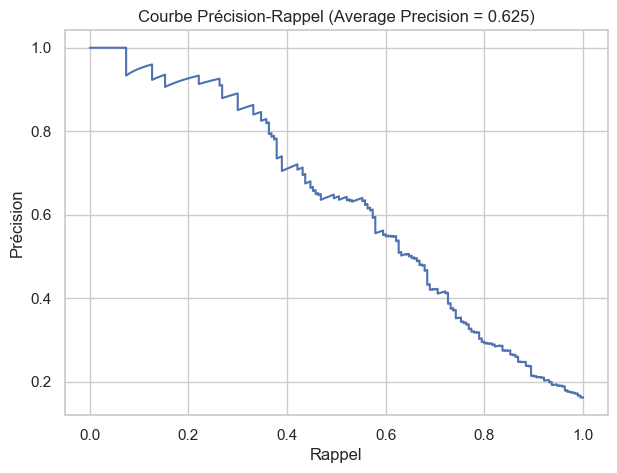

In [16]:
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_train, oof_proba_best) # teste tous les seuils et renvoie 3 tableaux
ap_score = average_precision_score(y_train, oof_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(recall_arr, precision_arr)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title(f"Courbe Précision-Rappel (Average Precision = {ap_score:.3f})")
plt.show()

In [17]:
threshold_table = pd.DataFrame({
    "threshold": thresholds_arr,
    "precision": precision_arr[:-1],
    "recall": recall_arr[:-1]
})

# On calcule le F1 pour chaque seuil
threshold_table["f1"] = (
    2 * threshold_table["precision"] * threshold_table["recall"]
    / (threshold_table["precision"] + threshold_table["recall"]).replace(0, np.nan)
)

threshold_table.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1
1009,0.618615,0.634731,0.557895,0.593838
1012,0.620434,0.640244,0.552632,0.593220
1005,0.616585,0.625731,0.563158,0.592798
998,0.606276,0.612360,0.573684,0.592391
1008,0.618300,0.630952,0.557895,0.592179
1001,0.612624,0.617143,0.568421,0.591781
1011,0.619464,0.636364,0.552632,0.591549
1004,0.616068,0.622093,0.563158,0.591160
997,0.605150,0.608939,0.573684,0.590786
1007,0.618009,0.627219,0.557895,0.590529


### Seuil F1-optimal

C'est le seuil qui maximise le F1-score, soit le meilleur compromis entre précision et rappel.

In [18]:
best_row_f1 = threshold_table.sort_values("f1", ascending=False).iloc[0] # on prend la meilleure ligne en fonction du f1
threshold_f1 = best_row_f1["threshold"] # on prend le seuil associé

print(f"Seuil F1-optimal : {threshold_f1:.3f}")
print(f"  Précision = {best_row_f1['precision']:.3f}")
print(f"  Rappel    = {best_row_f1['recall']:.3f}")
print(f"  F1        = {best_row_f1['f1']:.3f}")

Seuil F1-optimal : 0.619
  Précision = 0.635
  Rappel    = 0.558
  F1        = 0.594


### Seuil métier

Dans le contexte RH, un faux négatif (un employé à risque non détecté) est plus coûteux qu'un faux positif (une alerte qui mène à un simple entretien préventif).  
On cherche donc un seuil qui garantit au moins 60 % de rappel, tout en gardant le meilleur F1 possible.

In [19]:
candidates = threshold_table[threshold_table["recall"] >= 0.60] # au moins 60% de rappel
best_row_metier = candidates.sort_values("f1", ascending=False).iloc[0]
threshold_metier = best_row_metier["threshold"]

print(f"Seuil métier (rappel >= 0.60) : {threshold_metier:.3f}")
print(f"  Précision = {best_row_metier['precision']:.3f}")
print(f"  Rappel    = {best_row_metier['recall']:.3f}")
print(f"  F1        = {best_row_metier['f1']:.3f}")

Seuil métier (rappel >= 0.60) : 0.562
  Précision = 0.549
  Rappel    = 0.621
  F1        = 0.583


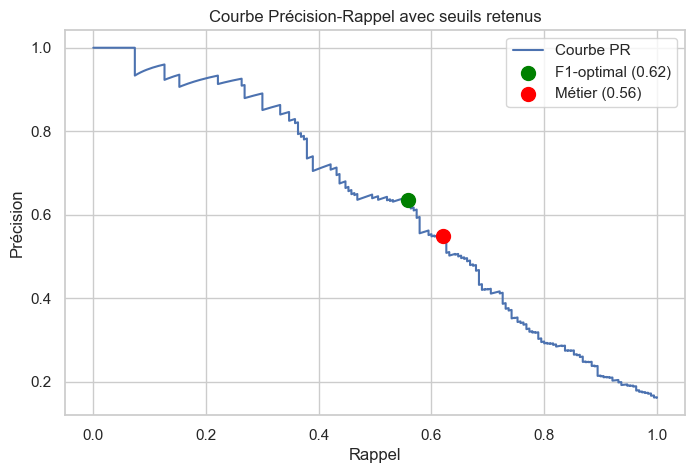

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(recall_arr, precision_arr, label="Courbe PR")

plt.scatter([best_row_f1["recall"]], [best_row_f1["precision"]],
            color="green", s=100, zorder=5, label=f"F1-optimal ({threshold_f1:.2f})")
plt.scatter([best_row_metier["recall"]], [best_row_metier["precision"]],
            color="red", s=100, zorder=5, label=f"Métier ({threshold_metier:.2f})")

plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel avec seuils retenus")
plt.legend()
plt.show()

## Évaluation finale sur le jeu de test

On entraîne le modèle final sur l'ensemble du jeu d'entraînement, puis on évalue sur le jeu de test.  
Les métriques sont calculées sur le train et sur le test pour mesurer le surapprentissage.

In [21]:
if best_approach == "SMOTE":
    smote_final = SMOTE(random_state=42)
    X_train_fit, y_train_fit = smote_final.fit_resample(X_train, y_train)
    spw_final = 1.0
    print(f"SMOTE appliqué : {X_train_fit.shape[0]} observations (vs {X_train.shape[0]} avant)")
else:
    X_train_fit = X_train
    y_train_fit = y_train
    spw_final = scale_pos_weight
    print(f"scale_pos_weight appliqué : {spw_final:.2f}")

final_model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=3.0,
    gamma=0.3,
    scale_pos_weight=spw_final,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

final_model.fit(X_train_fit, y_train_fit)

scale_pos_weight appliqué : 5.19


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [22]:
train_proba = final_model.predict_proba(X_train)[:, 1]
test_proba = final_model.predict_proba(X_test)[:, 1]

### Rapport de classification avec le seuil F1-optimal

In [23]:
y_train_pred_f1 = (train_proba >= threshold_f1).astype(int)
y_test_pred_f1 = (test_proba >= threshold_f1).astype(int)

print(f"Seuil F1-optimal : {threshold_f1:.3f}")

print("\n--- Train ---")
print(classification_report(y_train, y_train_pred_f1, zero_division=0))

print("--- Test ---")
print(classification_report(y_test, y_test_pred_f1, zero_division=0))

Seuil F1-optimal : 0.619

--- Train ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       986
           1       0.72      0.73      0.72       190

    accuracy                           0.91      1176
   macro avg       0.83      0.84      0.83      1176
weighted avg       0.91      0.91      0.91      1176

--- Test ---
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       247
           1       0.48      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294



### Rapport de classification avec le seuil métier

In [24]:
y_train_pred_metier = (train_proba >= threshold_metier).astype(int)
y_test_pred_metier = (test_proba >= threshold_metier).astype(int)

print(f"Seuil métier : {threshold_metier:.3f}")

print("\n--- Train ---")
print(classification_report(y_train, y_train_pred_metier, zero_division=0))

print("--- Test ---")
print(classification_report(y_test, y_test_pred_metier, zero_division=0))

Seuil métier : 0.562

--- Train ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       986
           1       0.65      0.78      0.71       190

    accuracy                           0.90      1176
   macro avg       0.81      0.85      0.83      1176
weighted avg       0.91      0.90      0.90      1176

--- Test ---
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       247
           1       0.44      0.57      0.50        47

    accuracy                           0.82       294
   macro avg       0.68      0.72      0.69       294
weighted avg       0.84      0.82      0.83       294



### Matrices de confusion

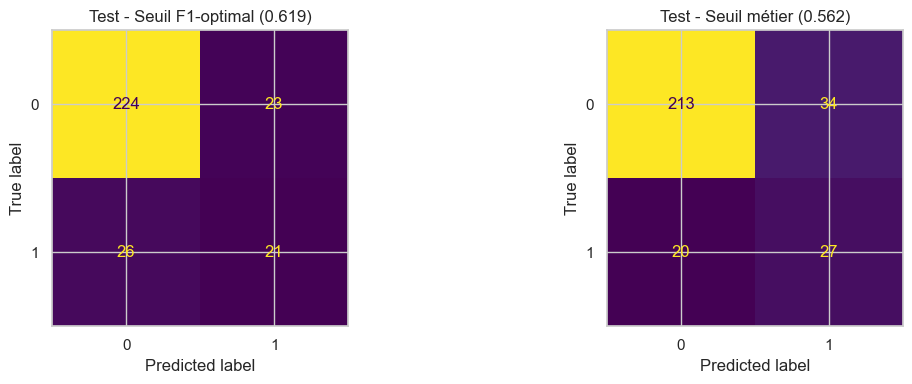

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_f1, ax=axes[0], colorbar=False)
axes[0].set_title(f"Test - Seuil F1-optimal ({threshold_f1:.3f})")

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_metier, ax=axes[1], colorbar=False)
axes[1].set_title(f"Test - Seuil métier ({threshold_metier:.3f})")

plt.tight_layout()
plt.show()

### Analyse du surapprentissage

In [26]:
print("Écart train / test (F1 sur classe 1) :")

for name, thr in [("F1-optimal", threshold_f1), ("Métier", threshold_metier)]:
    train_f1 = f1_score(y_train, (train_proba >= thr).astype(int), zero_division=0)
    test_f1 = f1_score(y_test, (test_proba >= thr).astype(int), zero_division=0)
    gap = train_f1 - test_f1
    print(f"  {name:12s} : Train F1 = {train_f1:.3f}, Test F1 = {test_f1:.3f}, Écart = {gap:.3f}")

Écart train / test (F1 sur classe 1) :
  F1-optimal   : Train F1 = 0.723, Test F1 = 0.462, Écart = 0.261
  Métier       : Train F1 = 0.713, Test F1 = 0.500, Écart = 0.213


## Interprétation

Le feature engineering a permis de créer 9 variables supplémentaires qui capturent des dimensions métier pertinentes.  
Le nombre de features passe de 39 à 48.

Deux approches de gestion du déséquilibre ont été testées en validation croisée :
- `scale_pos_weight` pondère la classe minoritaire directement dans XGBoost
- SMOTE génère des exemples synthétiques, appliqué uniquement dans chaque fold d'entraînement

Le seuil de décision a été ajusté via la courbe précision-rappel :
- le seuil F1-optimal offre le meilleur compromis entre précision et rappel
- le seuil métier privilégie le rappel, car dans le contexte RH il est préférable d'enquêter sur un faux positif que de rater un vrai départ

Le modèle surpasse nettement le Dummy et détecte des patterns utiles, ce qui est suffisant pour identifier les facteurs les plus influents via SHAP.